In [1]:
import pandas as pd

# Veriyi yükleyelim
df = pd.read_csv('legal_text_classification.csv')

# İlk birkaç satırı inceleyelim
print(df.head())


C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


  case_id case_outcome                                         case_title  \
0   Case1        cited  Alpine Hardwood (Aust) Pty Ltd v Hardys Pty Lt...   
1   Case2        cited  Black v Lipovac [1998] FCA 699 ; (1998) 217 AL...   
2   Case3        cited  Colgate Palmolive Co v Cussons Pty Ltd (1993) ...   
3   Case4        cited  Dais Studio Pty Ltd v Bullett Creative Pty Ltd...   
4   Case5        cited  Dr Martens Australia Pty Ltd v Figgins Holding...   

                                           case_text  
0  Ordinarily that discretion will be exercised s...  
1  The general principles governing the exercise ...  
2  Ordinarily that discretion will be exercised s...  
3  The general principles governing the exercise ...  
4  The preceding general principles inform the ex...  


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Drop rows with missing text
df_clean = df.dropna(subset=['case_text'])

# Preprocessing function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df_clean['clean_text'] = df_clean['case_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ÇELİK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\ÇELİK\AppData\Local\Temp\ipykernel_1676\363138237.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['clean_text'] = df_clean['case_text'].apply(clean_text)


# Topic Modeling (LDA) ile Metinlerden Ana Temaları Bulma

Topic 1:
  act: 10322.18
  decision: 8428.10
  evidence: 7692.90
  law: 6696.27
  fcr: 5796.58
  case: 5689.88
  commission: 5635.91
  court: 5433.71
  mr: 5350.55
  clr: 5127.87
--------------------------------------------------------------------------------
Topic 2:
  pty: 15075.40
  court: 14619.82
  order: 10359.56
  costs: 10075.61
  case: 9770.15
  mr: 9318.98
  party: 5833.35
  company: 5601.38
  fca: 5250.15
  circumstances: 5174.27
--------------------------------------------------------------------------------
Topic 3:
  tribunal: 23324.28
  court: 16946.16
  applicant: 15350.76
  minister: 13592.33
  decision: 13155.99
  appellant: 12645.91
  application: 10590.37
  immigration: 10284.74
  appeal: 9360.94
  affairs: 8563.94
--------------------------------------------------------------------------------
Topic 4:
  privilege: 13403.20
  awb: 13254.20
  legal: 12799.13
  documents: 11529.08
  advice: 10790.62
  document: 5981.38
  evidence: 5900.46
  waiver: 4808.19
  mark: 47

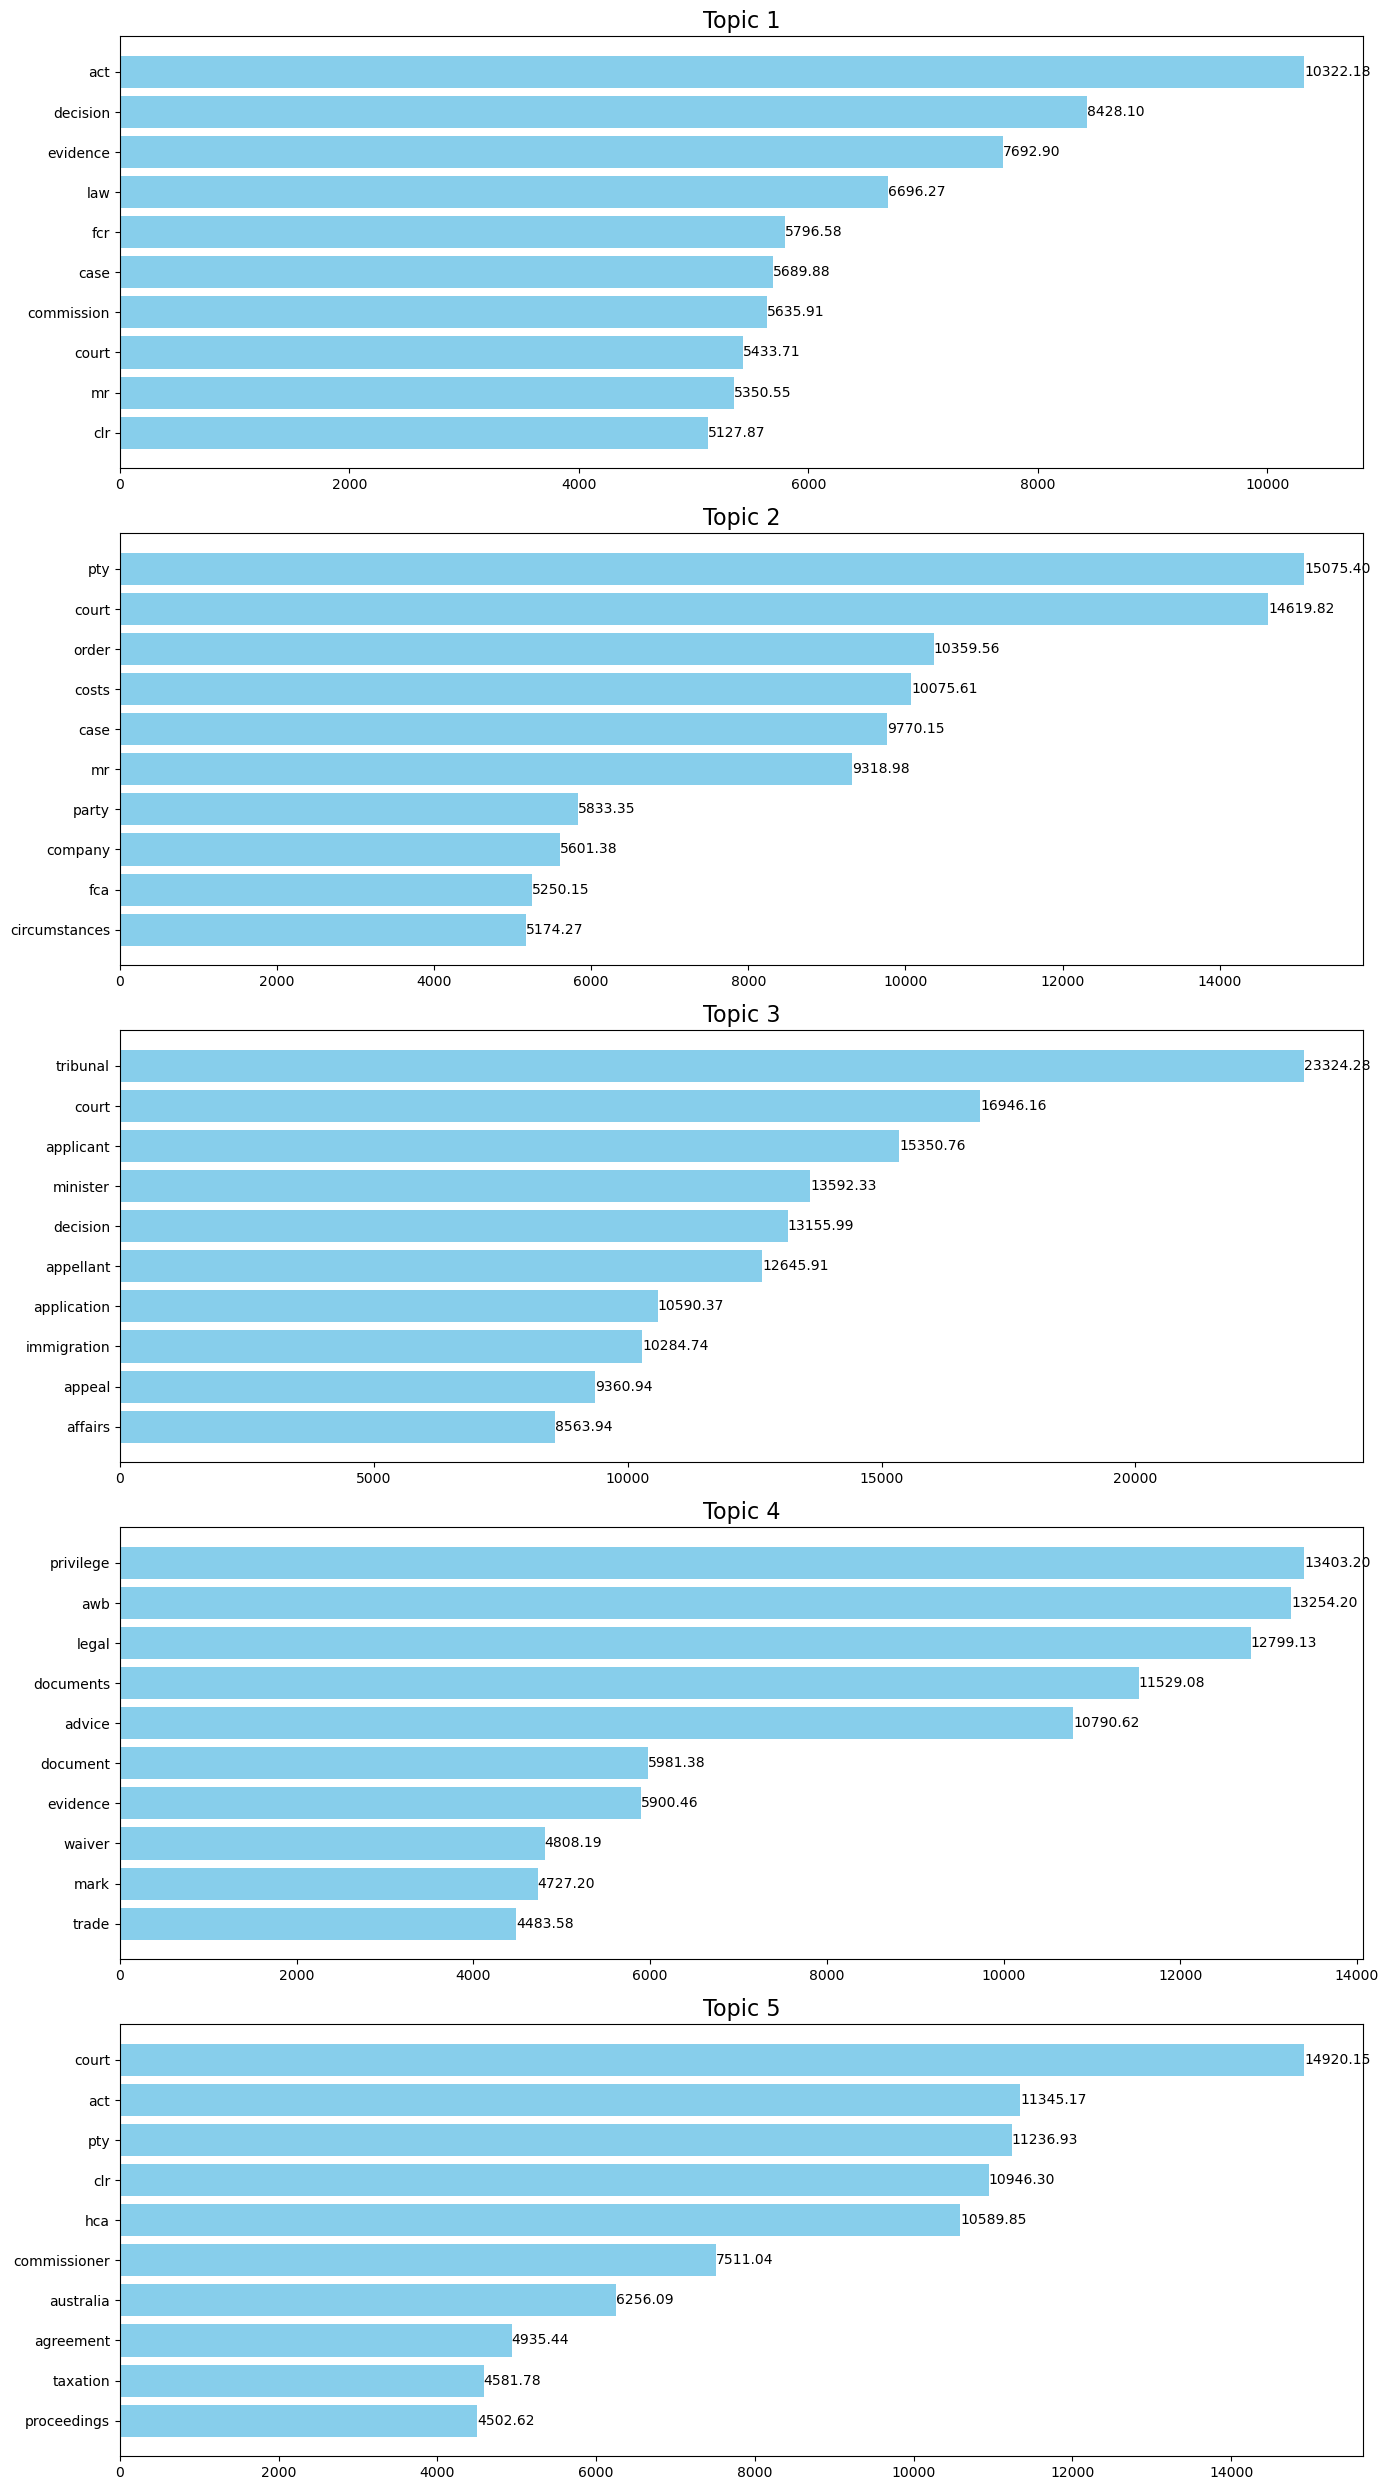

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Veri setini yükleme
data = pd.read_csv('legal_text_classification.csv')

# Dava metinlerini seçme
texts = data['case_text'].dropna()

# CountVectorizer ile kelime sayım matrisi oluşturma
count_vect = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X_counts = count_vect.fit_transform(texts)

# LDA modelini oluşturma ve eğitme
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_counts)

# Anahtar kelimeleri görselleştirme ve ağırlıkları yazdırma fonksiyonu
def plot_topics(model, feature_names, no_top_words):
    fig, axes = plt.subplots(5, 1, figsize=(14, 25))  # 5 konu için 5 alt grafik
    for idx, topic in enumerate(model.components_):
        top_features_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_indices]
        weights = topic[top_features_indices]
        
        # Konsola yazdır
        print(f"Topic {idx + 1}:")
        for word, weight in zip(top_features, weights):
            print(f"  {word}: {weight:.2f}")
        print("-" * 80)
        
        # Grafikte göster
        ax = axes[idx]
        bars = ax.barh(top_features, weights, color='skyblue')
        ax.set_title(f"Topic {idx + 1}", fontsize=16)
        ax.invert_yaxis()  # Kelimeler yukarıdan aşağı sıralansın
        
        # Her bar'ın sonuna değerleri yaz
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{width:.2f}', va='center', fontsize=10, color='black')

    plt.tight_layout()
    plt.savefig('lda_topics_with_values.jpg', format='jpg')
    plt.show()

# Fonksiyonu çağır
plot_topics(lda, count_vect.get_feature_names_out(), 10)

# Cosine Similarity ile Metin Benzerliği

In [ ]:
# Gerekli kütüphaneleri yükleyelim
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Veri Setini Okuma
df = pd.read_csv('legal_text_classification.csv')

# 2. Metinleri seçelim
texts = df['case_text'].astype(str)

# 3. TF-IDF Vektörleştirme
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85)
X_tfidf = vectorizer.fit_transform(texts)

# 4. Cosine Similarity Matrisi
cos_sim = cosine_similarity(X_tfidf)

# 5. Hangi iki dava için benzerlik bakılacak? (Burada değiştirebilirsin)
case_index_1 = 0  # Örnek: 10. indexteki dava
case_index_2 = 50  # Örnek: 100. indexteki dava

# 6. Bir fonksiyon ile belirli case için benzer davaları bulalım
def find_similar_cases(case_index, top_n=5):
    similarities = cos_sim[case_index]
    top_matches = similarities.argsort()[::-1][1:top_n+1]  # En yüksek skorlu ilk 5 taneyi alıyoruz
    results = []
    for idx in top_matches:
        case_id = df.iloc[idx]['case_id']
        case_title = df.iloc[idx]['case_title']
        similarity_score = similarities[idx]
        excerpt = texts.iloc[idx][:300]  # İlk 300 karakterlik özet
        results.append({
            'Case ID': case_id,
            'Case Title': case_title,
            'Similarity Score': f"{similarity_score:.3f}",
            'Excerpt': excerpt
        })
    results_df = pd.DataFrame(results)
    return results_df

# 7. Her iki dava için ayrı ayrı benzerlikleri bulalım ve yazdıralım
results_case_1 = find_similar_cases(case_index_1)
results_case_2 = find_similar_cases(case_index_2)

print(f"\nMost Similar Cases to Case {case_index_1}:")
print(results_case_1)

print(f"\nMost Similar Cases to Case {case_index_2}:")
print(results_case_2)


In [ ]:
# Gerekli kütüphaneleri yükleyelim
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Veri Setini Okuma
df = pd.read_csv('legal_text_classification.csv')

# 2. Metinleri seçelim
texts = df['case_text'].astype(str)

# 3. TF-IDF Vektörleştirme
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.85)
X_tfidf = vectorizer.fit_transform(texts)

# 4. Cosine Similarity Matrisi
cos_sim = cosine_similarity(X_tfidf)

# 5. Hangi iki dava için benzerlik bakılacak? (Burada değiştirebilirsin)
case_index_1 = 30  # Örnek: 30. indexteki dava
case_index_2 = 50  # Örnek: 50. indexteki dava

# 6. Bir fonksiyon ile belirli case için benzer davaları bulalım
def find_similar_cases(case_index, top_n=5):
    similarities = cos_sim[case_index]
    top_matches = similarities.argsort()[::-1][1:top_n+1]  # En yüksek skorlu ilk 5 taneyi alıyoruz
    results = []
    for idx in top_matches:
        case_id = df.iloc[idx]['case_id']
        case_title = df.iloc[idx]['case_title']
        similarity_score = similarities[idx]
        excerpt = texts.iloc[idx][:300]  # İlk 300 karakterlik özet
        results.append({
            'Case ID': case_id,
            'Case Title': case_title,
            'Similarity Score': f"{similarity_score:.3f}",
            'Excerpt': excerpt
        })
    results_df = pd.DataFrame(results)
    return results_df

# 7. Her iki dava için ayrı ayrı benzerlikleri bulalım ve yazdıralım
results_case_1 = find_similar_cases(case_index_1)
results_case_2 = find_similar_cases(case_index_2)

print(f"\nMost Similar Cases to Case {case_index_1}:")
print(results_case_1)

print(f"\nMost Similar Cases to Case {case_index_2}:")
print(results_case_2)

# Benzer Kararları Bulma (Semantic Similarity Search)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Dosyayı oku ve boş case_text'leri at
df = pd.read_csv("legal_text_classification.csv")
df = df.dropna(subset=['case_text'])  # ✔️ NaN olan satırları temizle

texts = df['case_text'].tolist()

# TF-IDF vektörleştirme
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(texts)

# Sorgu metni
query = "The contract dispute regarding intellectual property"
query_vec = vectorizer.transform([query])

# Benzerlik hesapla
similarities = cosine_similarity(query_vec, X_vec).flatten()
top_indices = similarities.argsort()[-5:][::-1]

# Sonuçları yazdır
print("Most similar cases:\n")
for i in top_indices:
    print(f"Case Title: {df.iloc[i]['case_title']}")
    print(df.iloc[i]['case_text'][:300], '...\n')

In [ ]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

# Veri setini oku ve NaN satırları temizle
df = pd.read_csv("legal_text_classification.csv")
df = df.dropna(subset=['case_text'])

# Cinsiyet temelli anahtar kelimeler
gender_terms = {
    "male": ["he", "him", "his", "man", "men", "boy", "father", "husband"],
    "female": ["she", "her", "hers", "woman", "women", "girl", "mother", "wife"]
}

# Sayım fonksiyonu
def count_terms(text, term_list):
    if not isinstance(text, str):
        return 0
    text = text.lower()
    return sum(text.count(term) for term in term_list)

# Sayıları hesapla
df['male_mentions'] = df['case_text'].apply(lambda x: count_terms(x, gender_terms['male']))
df['female_mentions'] = df['case_text'].apply(lambda x: count_terms(x, gender_terms['female']))

# Histogram çizimi
plt.figure(figsize=(12, 6))

# Ortak binler belirle
max_count = max(df['male_mentions'].max(), df['female_mentions'].max())
bins = range(0, max_count + 2)  # 1'er 1'er aralıklarla

# Histogramları çiz
plt.hist(df['male_mentions'], bins=bins, alpha=0.5, label='Male Mentions', color='blue', edgecolor='black', density=False)
plt.hist(df['female_mentions'], bins=bins, alpha=0.5, label='Female Mentions', color='pink', edgecolor='black', density=False)

# Grafik ayarları
plt.legend()
plt.title("Distribution of Gender-Related Term Mentions in Judicial Texts")
plt.xlabel("Number of Mentions per Document")
plt.ylabel("Number of Documents")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 📄 Toplam istatistikleri yazdır
print(f"Total male term mentions across all documents: {df['male_mentions'].sum()}")
print(f"Total female term mentions across all documents: {df['female_mentions'].sum()}")
print(f"Documents mentioning male terms: {sum(df['male_mentions'] > 0)}")
print(f"Documents mentioning female terms: {sum(df['female_mentions'] > 0)}")


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri
data = {
    "Metric": [
        "Total male term mentions",
        "Total female term mentions",
        "Documents mentioning male terms",
        "Documents mentioning female terms"
    ],
    "Value": [1440253, 167725, 24776, 21557]
}

# DataFrame oluştur
summary_df = pd.DataFrame(data)

# Isı haritası
plt.figure(figsize=(8, 3))
pivot_df = summary_df.pivot_table(index="Metric", values="Value")
sns.heatmap(pivot_df, annot=True, fmt='g', cmap="YlGnBu", cbar=False)
plt.title("Summary of Gender-Term Mentions in Judicial Texts")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Hukuki Metinlerin Makine Öğrenmesi ile Sınıflandırılması: Lojistik Regresyon, Naive Bayes ve Linear SVM Yöntemlerinin Karşılaştırılması"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ÇELİK\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ÇELİK\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\ÇELİK\AppData\Local\Temp\ipykernel_1676\595902774.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'clean_text'] = df_clean['case_text'].apply(clean_text)



Class Distribution:
 case_outcome
cited            12110
referred to       4363
applied           2438
followed          2252
considered        1699
discussed         1018
distinguished      603
related            112
approved           108
affirmed           106
Name: count, dtype: int64

=== Logistic Regression ===
Classification Report:
                precision    recall  f1-score   support

     affirmed       0.83      0.22      0.34        23
      applied       0.30      0.06      0.11       496
     approved       0.00      0.00      0.00        21
        cited       0.56      0.94      0.70      2440
   considered       0.33      0.04      0.07       353
    discussed       0.43      0.05      0.09       206
distinguished       0.90      0.08      0.15       110
     followed       0.60      0.13      0.21       437
  referred to       0.56      0.38      0.45       855
      related       1.00      0.05      0.09        21

     accuracy                           0.55     

C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


=== Naive Bayes ===
Classification Report:
                precision    recall  f1-score   support

     affirmed       0.00      0.00      0.00        23
      applied       0.00      0.00      0.00       496
     approved       0.00      0.00      0.00        21
        cited       0.49      1.00      0.66      2440
   considered       0.00      0.00      0.00       353
    discussed       0.00      0.00      0.00       206
distinguished       0.00      0.00      0.00       110
     followed       0.00      0.00      0.00       437
  referred to       0.80      0.00      0.01       855
      related       0.00      0.00      0.00        21

     accuracy                           0.49      4962
    macro avg       0.13      0.10      0.07      4962
 weighted avg       0.38      0.49      0.33      4962

Confusion Matrix (Numeric Values):
 [[   0    0    0   23    0    0    0    0    0    0]
 [   0    0    0  496    0    0    0    0    0    0]
 [   0    0    0   21    0    0    0    

C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ÇELİK\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


=== Linear SVM ===
Classification Report:
                precision    recall  f1-score   support

     affirmed       0.64      0.39      0.49        23
      applied       0.35      0.23      0.28       496
     approved       0.25      0.14      0.18        21
        cited       0.66      0.83      0.73      2440
   considered       0.42      0.24      0.31       353
    discussed       0.43      0.21      0.29       206
distinguished       0.59      0.31      0.40       110
     followed       0.48      0.34      0.40       437
  referred to       0.57      0.56      0.57       855
      related       0.67      0.19      0.30        21

     accuracy                           0.59      4962
    macro avg       0.51      0.35      0.39      4962
 weighted avg       0.57      0.59      0.57      4962

Confusion Matrix (Numeric Values):
 [[   9    0    0   10    1    0    0    0    3    0]
 [   0  113    0  274   15    9    1   24   60    0]
 [   0    2    3    9    2    1    0    2

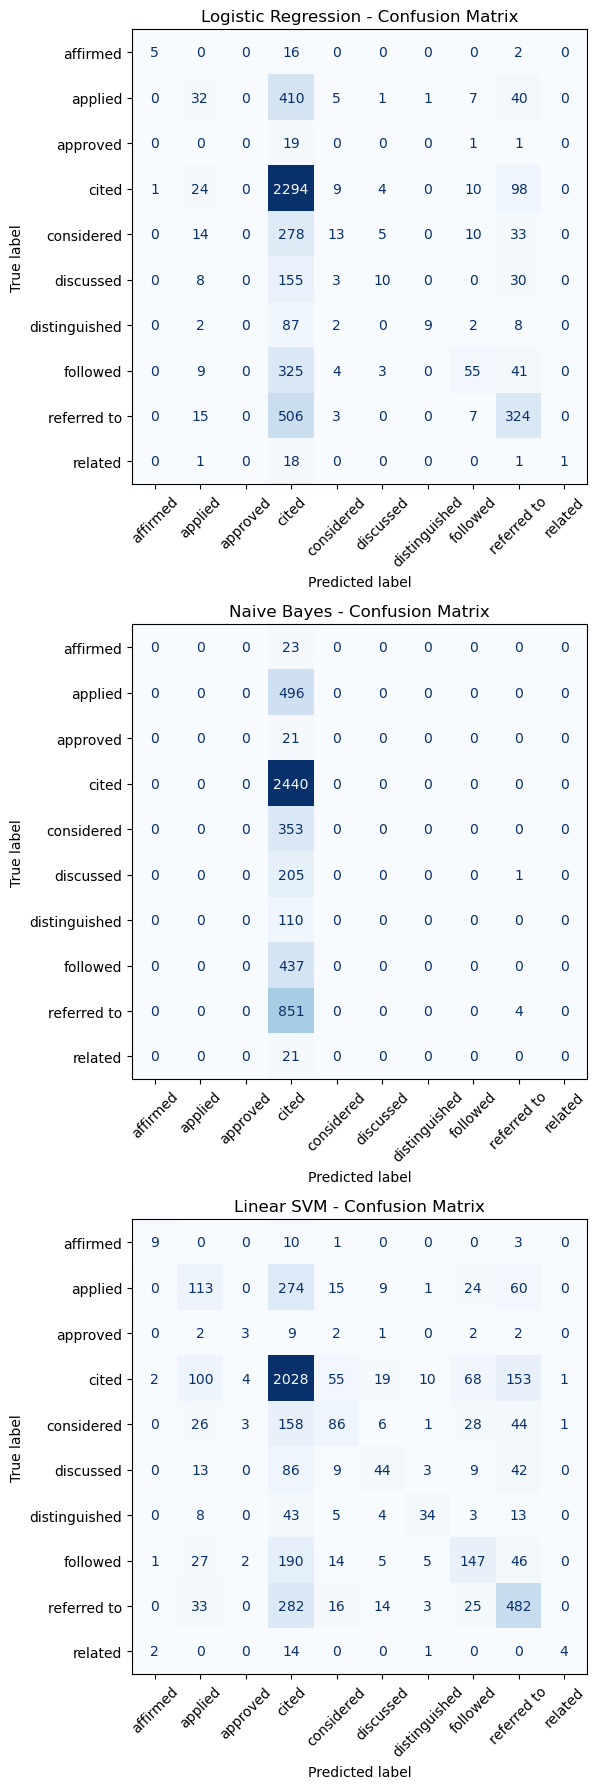

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# NLTK Kurulum
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Veri Yükleme
df = pd.read_csv("legal_text_classification.csv")
df_clean = df.dropna(subset=['case_text'])

# Metin Temizleme ve Lemmatization
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df_clean.loc[:, 'clean_text'] = df_clean['case_text'].apply(clean_text)

# Sınıf Dağılımı
print("\nClass Distribution:\n", df_clean['case_outcome'].value_counts())

# TF-IDF Vektörizasyon
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_clean['clean_text'])
y = df_clean['case_outcome']

# Eğitim-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeller
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

# Tüm Confusion Matrix'leri Alt Alta Plotlamak için Ayar
fig, axes = plt.subplots(nrows=len(models), ncols=1, figsize=(8, 18))

for idx, (name, clf) in enumerate(models.items()):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    print(f"\n=== {name} ===")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    # Sayısal Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    print("Confusion Matrix (Numeric Values):\n", cm)
    
    # Görsel Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{name} - Confusion Matrix")
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hukuki Metinlerin Makine Öğrenmesi ile Sınıflandırılması: Logistic Regression, Naive Bayes, Linear SVM ve SMOTE ile Dengeleme ve GridSearchCV Hiperparametre Optimizasyonu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# NLTK Kurulum
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Veri Yükleme
df = pd.read_csv("legal_text_classification.csv")
df_clean = df.dropna(subset=['case_text'])

# Metin Temizleme ve Lemmatization
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df_clean.loc[:, 'clean_text'] = df_clean['case_text'].apply(clean_text)

# Sınıf Etiketlerini Encode Et
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean['case_outcome'])
X_text = df_clean['clean_text']

# TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X_text)

# SMOTE ile Dengeleme
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Eğitim-Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Logistic Regression için GridSearchCV
log_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
log_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
log_grid.fit(X_train, y_train)

log_best_model = log_grid.best_estimator_
log_y_pred = log_best_model.predict(X_test)

print(f"\nBest Parameters (Logistic Regression): {log_grid.best_params_}")
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, log_y_pred))

# Naive Bayes için GridSearchCV
nb_param_grid = {
    'alpha': [0.1, 1, 10]
}
nb_grid = GridSearchCV(MultinomialNB(), nb_param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
nb_grid.fit(X_train, y_train)

nb_best_model = nb_grid.best_estimator_
nb_y_pred = nb_best_model.predict(X_test)

print(f"\nBest Parameters (Naive Bayes): {nb_grid.best_params_}")
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test, nb_y_pred))

# Linear SVM için GridSearchCV (kernel parametresiz)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],  # LinearSVC için penalti tipini belirtiyoruz
    'loss': ['squared_hinge']  # LinearSVC için kayıp fonksiyonunu belirtiyoruz
}
svm_grid = GridSearchCV(LinearSVC(max_iter=1000, random_state=42), svm_param_grid, cv=5, n_jobs=-1, scoring='f1_macro')
svm_grid.fit(X_train, y_train)

svm_best_model = svm_grid.best_estimator_
svm_y_pred = svm_best_model.predict(X_test)

print(f"\nBest Parameters (Linear SVM): {svm_grid.best_params_}")
print("\nClassification Report (Linear SVM):\n", classification_report(y_test, svm_y_pred))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, log_y_pred, display_labels=label_encoder.classes_, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Confusion Matrix for Naive Bayes
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, nb_y_pred, display_labels=label_encoder.classes_, cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Confusion Matrix for Linear SVM
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, svm_y_pred, display_labels=label_encoder.classes_, cmap='Blues')
plt.title("Linear SVM Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cross-validation for Logistic Regression
log_cv_scores = cross_val_score(log_best_model, X_resampled, y_resampled, cv=5, scoring='f1_macro')
print(f"\nCross-validation F1 Macro scores (Logistic Regression): {log_cv_scores}")
print(f"Mean F1 Macro (Logistic Regression): {np.mean(log_cv_scores):.4f}")

# Cross-validation for Naive Bayes
nb_cv_scores = cross_val_score(nb_best_model, X_resampled, y_resampled, cv=5, scoring='f1_macro')
print(f"\nCross-validation F1 Macro scores (Naive Bayes): {nb_cv_scores}")
print(f"Mean F1 Macro (Naive Bayes): {np.mean(nb_cv_scores):.4f}")

# Cross-validation for Linear SVM
svm_cv_scores = cross_val_score(svm_best_model, X_resampled, y_resampled, cv=5, scoring='f1_macro')
print(f"\nCross-validation F1 Macro scores (Linear SVM): {svm_cv_scores}")
print(f"Mean F1 Macro (Linear SVM): {np.mean(svm_cv_scores):.4f}")


In [ ]:
# Confusion Matrix ve Sayısal Değerler - Tek Sütun Halinde

fig, axs = plt.subplots(3, 1, figsize=(8, 18))  # 3 satır, 1 sütun

# Logistic Regression
cm_log = confusion_matrix(y_test, log_y_pred)
print("\n=== Logistic Regression Confusion Matrix (Numeric Values) ===")
print(cm_log)
ConfusionMatrixDisplay(cm_log, display_labels=label_encoder.classes_).plot(ax=axs[0], cmap='Blues', colorbar=False)
axs[0].set_title("Logistic Regression Confusion Matrix")
axs[0].tick_params(axis='x', rotation=45)

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_y_pred)
print("\n=== Naive Bayes Confusion Matrix (Numeric Values) ===")
print(cm_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=label_encoder.classes_).plot(ax=axs[1], cmap='Blues', colorbar=False)
axs[1].set_title("Naive Bayes Confusion Matrix")
axs[1].tick_params(axis='x', rotation=45)

# Linear SVM
cm_svm = confusion_matrix(y_test, svm_y_pred)
print("\n=== Linear SVM Confusion Matrix (Numeric Values) ===")
print(cm_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=label_encoder.classes_).plot(ax=axs[2], cmap='Blues', colorbar=False)
axs[2].set_title("Linear SVM Confusion Matrix")
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()